# 이상 구간 뷰어 — 사이클 단위 모델

`Cycle_AE_v2.ipynb` 가 학습해 둔 모델을 **그대로 불러와서** 점수만 매긴다 (재학습 없음).

한 번 돌리면 결과를 `cache/` 에 저장해서, 다음부터는 DB 조회 없이 몇 초 만에 뜬다.
**다시 뽑고 싶으면 `FORCE_REFRESH = True`** 로 바꾸면 된다.

보는 순서
1. 날짜 x 시간 히트맵 — 언제 문제가 몰렸는지
2. 문제가 있는 날 하루 펼쳐보기
3. 그 날 이상들의 피처 기여도 — 무엇 때문인지
4. 개별 이상 시점 원본 확대 — 실제로 무슨 일이 있었는지

In [1]:
import os, sys, pickle
ROOT_DIR = os.path.dirname(os.getcwd())
sys.path.insert(0, ROOT_DIR); sys.path.insert(0, os.getcwd())

import numpy as np, pandas as pd, torch, joblib
import matplotlib.pyplot as plt

from Log_Extractor import LogExtractor
import Anomaly_Viewer as V

pd.set_option("display.width", 200)

In [2]:
PUMP_ID = "P1"
START = "2026-09-10T07:00:00Z"      # 볼 구간 (넓게 잡아도 캐시되니 한 번만 느림)
END = "2026-09-23T18:00:00Z"   # 고정
FORCE_REFRESH = False               # True 로 바꾸면 DB에서 다시 뽑는다

CACHE = V.cache_path(f"viewer_cycle_{PUMP_ID}.pkl")
MODEL_DIR = os.path.join(os.getcwd(), "models_v2")

In [3]:
from Cycle_Feature_Extractor import extract_cycle_features, PUMP_MAP
from Cycle_AE import CycleAutoencoder

FEATURE_COLS = ["N_Ticks","SV_mean","FT_mean","FT_max","FT_std","PT_mean","PT_max","PT_std",
    "Ana_Out_mean","Temp_mean","Prev_SV","Prev_SV_Diff","PreBuildUp_PT","PreBuildUp_FT",
    "PT_Jump_From_Pre","FT_Jump_From_Pre","Instant_FT_Error_Rate_mean","Instant_FT_Error_Rate_max",
    "Cum_FT_Error","RampUp_Time_Sec","DeltaP_over_Q","Current_Proxy_I","Steady_Std_PT","Steady_Std_FT",
    "Ramp_Negative_Slope_Count","Unexplained_PT_Dip_Count","Unexplained_PT_Dip_Max",
    "Unexplained_FT_Dip_Count","Unexplained_FT_Dip_Max","Decay_Slope_PT","Decay_Slope_FT"]

info = PUMP_MAP[PUMP_ID]
HEAD, ROBOT, SLOT = info["head"], info["robot"], info["slot"]
INJ_COL = f"Shot_Injection_{HEAD}_P{SLOT}"
TAGS = [f"Pump_BuildUp_{PUMP_ID}", f"g_s_SV_{PUMP_ID}", f"Scale_Out___FT_{PUMP_ID}",
        f"Scale_Out___PT_{PUMP_ID}", f"Ana_Out_{PUMP_ID}", f"TK_Temp_PV_{PUMP_ID}",
        f"Hz_Out_{PUMP_ID}", INJ_COL, f"{ROBOT}_Robot_Num", "AL_Line_Bit"] \
       + [f"{HEAD}_FOAMING_SHOT{k}" for k in range(1, 7)]

if (not FORCE_REFRESH) and os.path.exists(CACHE):
    with open(CACHE, "rb") as f:
        store = pickle.load(f)
    print(f"캐시에서 로드: {CACHE}")
else:
    print("DB에서 추출 중... (처음 한 번만 느립니다)")
    ex = LogExtractor(env_path=os.path.join(ROOT_DIR, ".env"))
    raw = ex.get_data(start_time=START, end_time=END, target_tags=TAGS)
    cyc, _ = extract_cycle_features(raw, PUMP_ID)
    cyc = cyc[cyc["Prev_SV"] != 0].dropna(subset=FEATURE_COLS)

    scaler = joblib.load(os.path.join(MODEL_DIR, f"scaler_cycle_{PUMP_ID}.pkl"))
    model = CycleAutoencoder(len(FEATURE_COLS))
    model.load_state_dict(torch.load(os.path.join(MODEL_DIR, f"autoencoder_cycle_{PUMP_ID}.pth"),
                                     weights_only=True))
    model.eval()

    X = scaler.transform(cyc[FEATURE_COLS])
    with torch.no_grad():
        t = torch.FloatTensor(X)
        pf = ((t - model(t)) ** 2).numpy()
    cyc["Recon_Error"] = pf.mean(axis=1)

    store = {"cyc": cyc, "per_feat": pf, "raw": raw}
    with open(CACHE, "wb") as f:
        pickle.dump(store, f)
    print(f"캐시 저장: {CACHE}")

cyc, per_feat, raw = store["cyc"], store["per_feat"], store["raw"]

# 임계치는 학습 기간(Train) 분포의 99퍼센타일과 같은 방식으로 다시 잡는다
TRAIN_END = pd.Timestamp("2026-09-18 16:00:00")   # KST 기준 학습 종료
train_mask = cyc["Start_Time"] < TRAIN_END
THRESHOLD = float(np.percentile(cyc.loc[train_mask, "Recon_Error"], 99))

print(f"\n사이클 {len(cyc):,}개 | 임계치 {THRESHOLD:.4f} | "
      f"이상 {int((cyc['Recon_Error']>THRESHOLD).sum()):,}건 "
      f"({(cyc['Recon_Error']>THRESHOLD).mean()*100:.2f}%)")

DB에서 추출 중... (처음 한 번만 느립니다)
🔌 [Extractor] InfluxDB 분석용 추출기 연결 완료!
🚀 추출 시작: 2026-09-10T07:00:00+00:00 ~ 2026-09-23T05:16:03.970313+00:00
   태그 16개 · 앞쪽 600초는 결측 복원용으로 더 받습니다
📦 [Chunk] 2026-09-10T06:50:00Z ~ 2026-09-10T12:50:00Z ... 

39428행
📦 [Chunk] 2026-09-10T12:50:00Z ~ 2026-09-10T18:50:00Z ... 

35983행
📦 [Chunk] 2026-09-10T18:50:00Z ~ 2026-09-11T00:50:00Z ... 

37083행
📦 [Chunk] 2026-09-11T00:50:00Z ~ 2026-09-11T06:50:00Z ... 

38257행
📦 [Chunk] 2026-09-11T06:50:00Z ~ 2026-09-11T12:50:00Z ... 

...

35685행
📦 [Chunk] 2026-09-22T18:50:00Z ~ 2026-09-23T00:50:00Z ... 

36156행
📦 [Chunk] 2026-09-23T00:50:00Z ~ 2026-09-23T05:16:03Z ... 

28716행


✅ 통합 완료 — 1901416행 × 17컬럼
🌡️  온도 계열 컬럼 1개 — **단위가 태그마다 다르다.**
     TK_Temp_PV_P1            Scale_Max___TT_P1=1000 → 0.1℃ 단위, 값÷10
     ※ 2026-04 데이터는 Scale_Max___TT_P1=100 이었다. 지금은 1000 이라
       같은 태그가 22 → 228 로 찍힌다. 두 시기를 섞지 말 것.


캐시 저장: C:\Users\taetk\Documents\KTA_Train\parkkt\cache\viewer_cycle_P1.pkl

사이클 32,817개 | 임계치 0.3219 | 이상 422건 (1.29%)


## 1. 날짜 x 시간 히트맵

어느 날 어느 시간대에 이상이 몰렸는지 본다. **회색 칸은 데이터가 없는 시간**(야간 제외 구간,
일요일 무가동 등)이고, 숫자가 흐린 칸은 표본이 20개 미만이라 해석에 주의해야 한다.

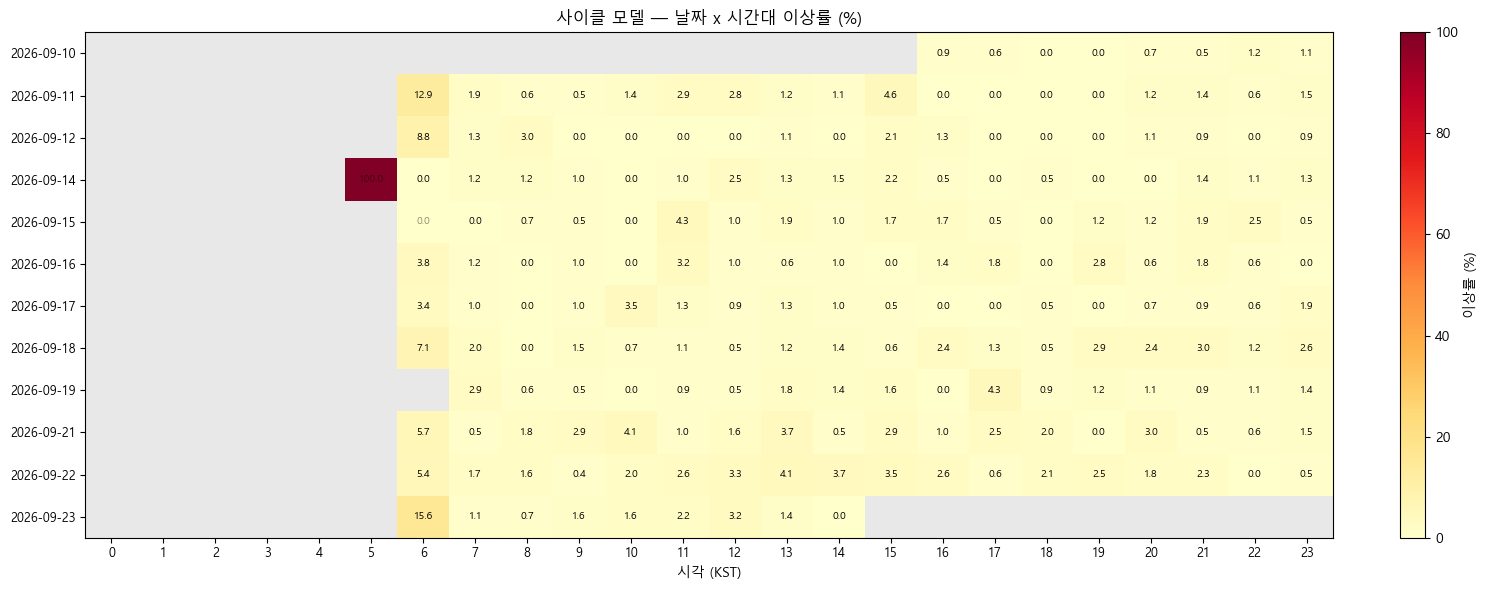

In [4]:
fig, piv_rate = V.hourly_heatmap(cyc, THRESHOLD, value="rate",
                                  title="사이클 모델 — 날짜 x 시간대 이상률 (%)")
plt.show()

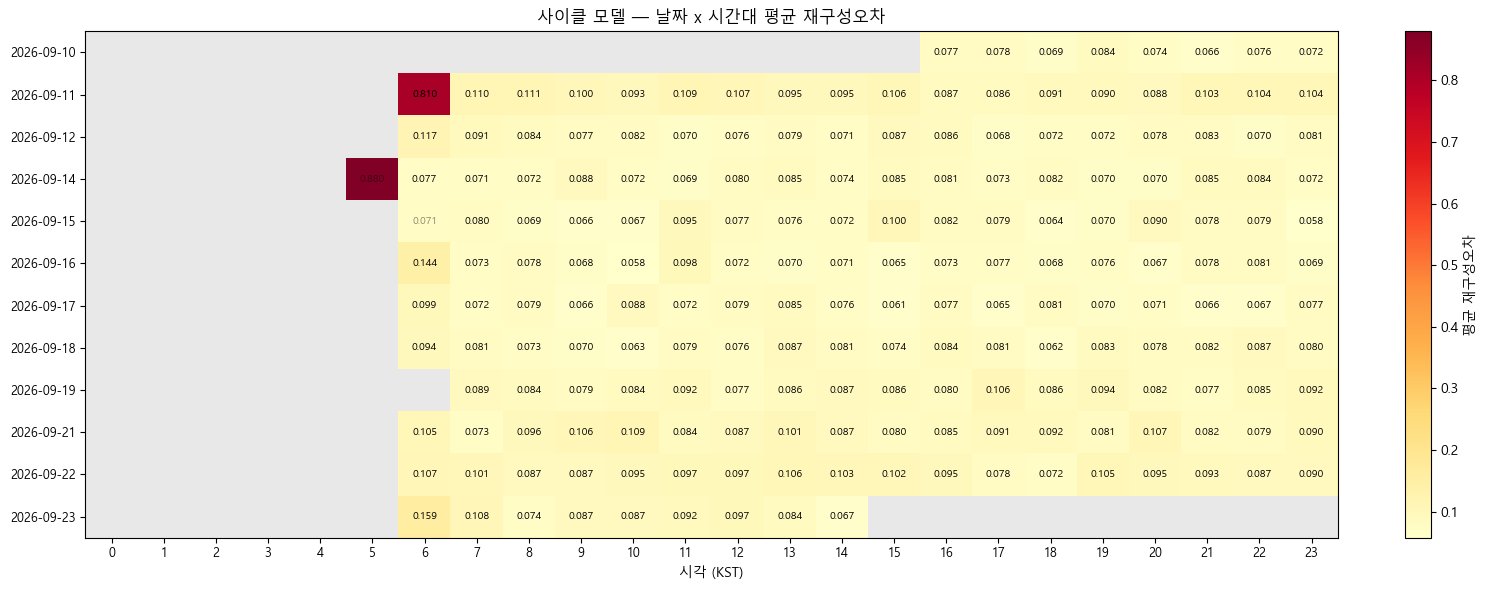

In [5]:
fig, piv_mean = V.hourly_heatmap(cyc, THRESHOLD, value="mean",
                                  title="사이클 모델 — 날짜 x 시간대 평균 재구성오차")
plt.show()

In [6]:
# 날짜별 요약 - 어느 날이 문제였나
d = V.add_time_cols(cyc)
d["is_anom"] = d["Recon_Error"] > THRESHOLD
daily = d.groupby("Date").agg(사이클수=("Recon_Error", "size"),
                              이상건수=("is_anom", "sum"),
                              평균오차=("Recon_Error", "mean"),
                              최대오차=("Recon_Error", "max"))
daily["이상률%"] = (daily["이상건수"] / daily["사이클수"] * 100).round(2)
daily = daily.round(4)
print(daily.to_string())
print("\n이상률 높은 순:")
print(daily.sort_values("이상률%", ascending=False).head(5).to_string())

            사이클수  이상건수    평균오차       최대오차  이상률%
Date                                           
2026-09-10  1368     9  0.0735   1.472600  0.66
2026-09-11  2943    40  0.1067  20.034401  1.36
2026-09-12  3237    26  0.0790   2.174000  0.80
2026-09-14  2844    30  0.0788   2.761600  1.05
2026-09-15  2942    32  0.0761   4.511800  1.09
2026-09-16  2965    27  0.0729   1.220200  0.91
2026-09-17  3013    27  0.0740   1.358400  0.90
2026-09-18  2916    45  0.0775   1.927200  1.54
2026-09-19  3129    38  0.0855   1.652900  1.21
2026-09-21  2962    54  0.0903   2.667000  1.82
2026-09-22  3330    71  0.0931   4.810000  2.13
2026-09-23  1168    23  0.0914   2.590700  1.97

이상률 높은 순:
            사이클수  이상건수    평균오차       최대오차  이상률%
Date                                           
2026-09-22  3330    71  0.0931   4.810000  2.13
2026-09-23  1168    23  0.0914   2.590700  1.97
2026-09-21  2962    54  0.0903   2.667000  1.82
2026-09-18  2916    45  0.0775   1.927200  1.54
2026-09-11  2943    40  0.106

## 2. 문제가 있는 날 하루 펼쳐보기

위 표에서 이상률이 높은 날짜를 `TARGET_DATE` 에 넣고 실행하면 그 하루가 펼쳐진다.

대상 날짜: 2026-09-22


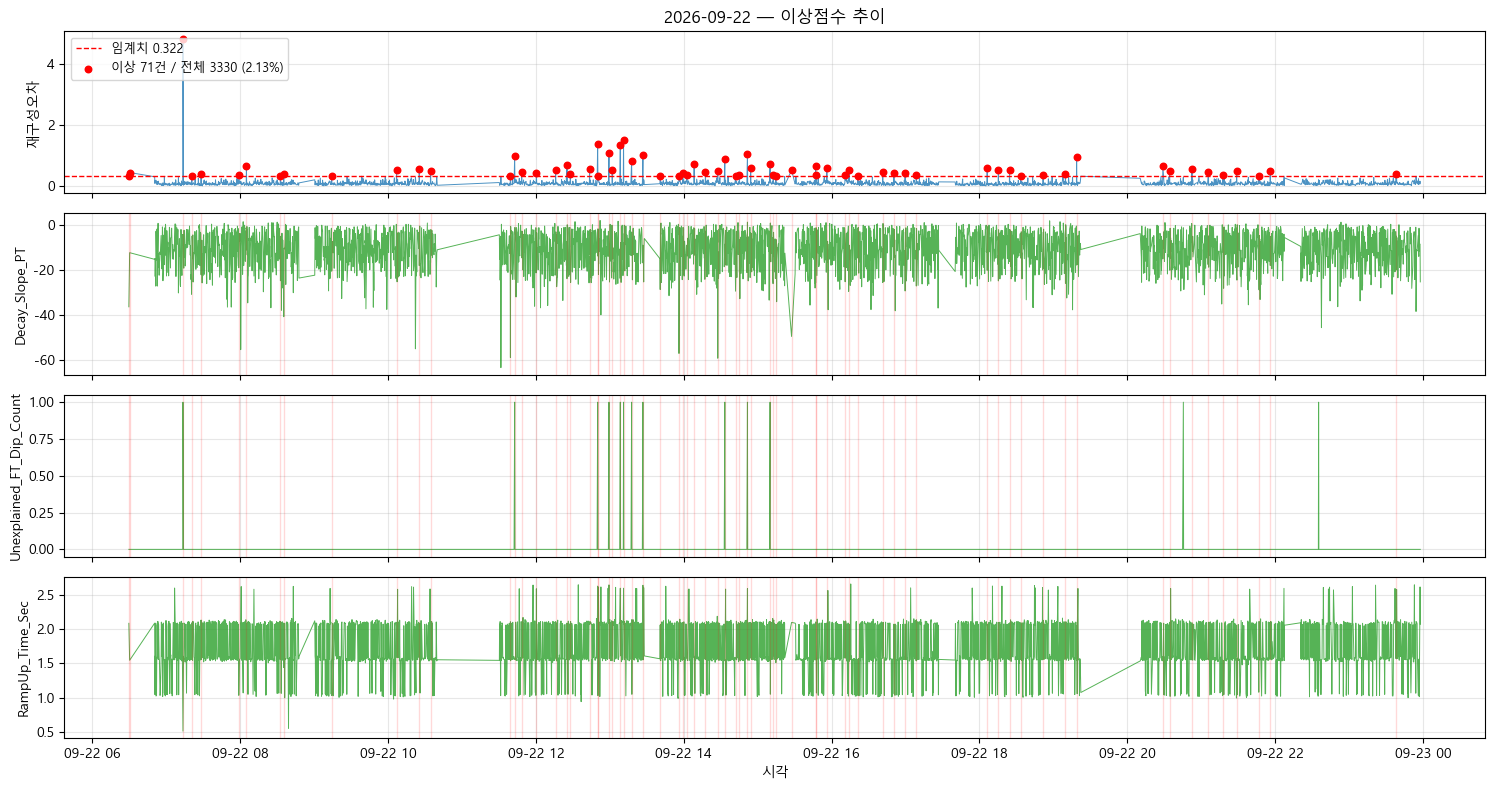

In [7]:
TARGET_DATE = daily.sort_values("이상률%", ascending=False).index[0]   # 가장 나쁜 날 자동 선택
print(f"대상 날짜: {TARGET_DATE}")

V.daily_detail(cyc, TARGET_DATE, THRESHOLD,
               extra_cols=["Decay_Slope_PT", "Unexplained_FT_Dip_Count", "RampUp_Time_Sec"])
plt.show()

## 3. 그 날 이상들은 무엇 때문이었나 — 피처 기여도 히트맵

가로축이 피처, 세로축이 이상 건(오차 큰 순). 진한 칸이 그 이상을 만든 주범이다.

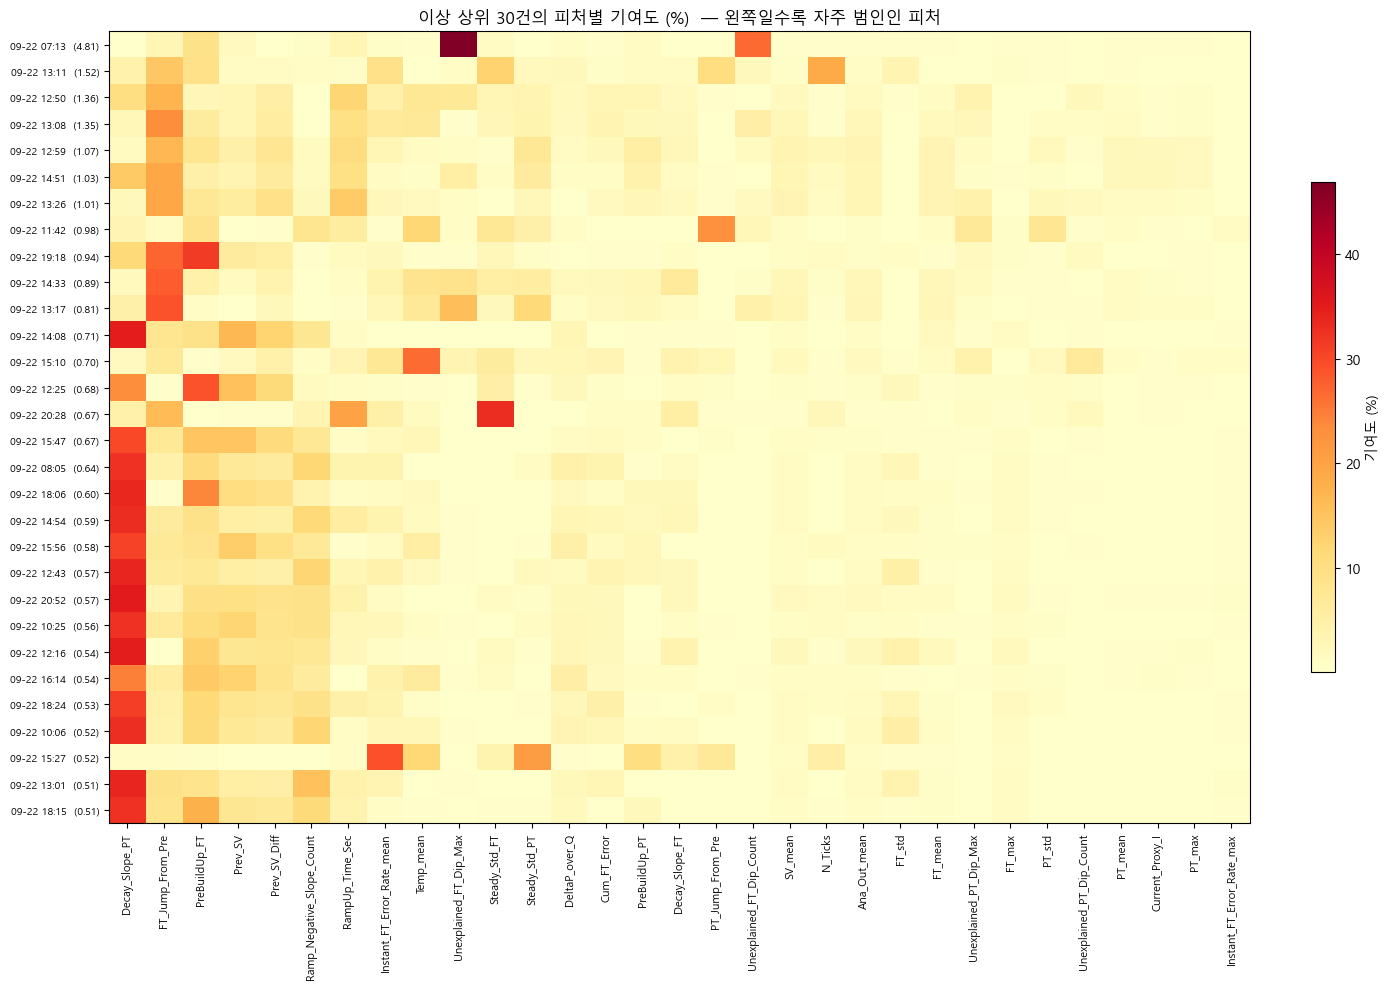

이 날 이상들에서 평균 기여도가 높은 피처 10개
Decay_Slope_PT                19.1
FT_Jump_From_Pre              10.2
PreBuildUp_FT                 10.1
Prev_SV                        6.4
Prev_SV_Diff                   6.1
Ramp_Negative_Slope_Count      5.4
RampUp_Time_Sec                4.4
Instant_FT_Error_Rate_mean     3.9
Temp_mean                      3.7
Unexplained_FT_Dip_Max         3.2


In [8]:
day_mask = (pd.to_datetime(cyc["Start_Time"]).dt.date == pd.to_datetime(TARGET_DATE).date()).values
fig, contrib = V.contribution_heatmap(
    per_feat[day_mask], FEATURE_COLS,
    cyc.loc[day_mask, "Recon_Error"].values,
    cyc.loc[day_mask, "Start_Time"].values,
    THRESHOLD, top_n=30)
plt.show()
if contrib is not None:
    print("이 날 이상들에서 평균 기여도가 높은 피처 10개")
    print(contrib.mean().sort_values(ascending=False).head(10).round(1).to_string())

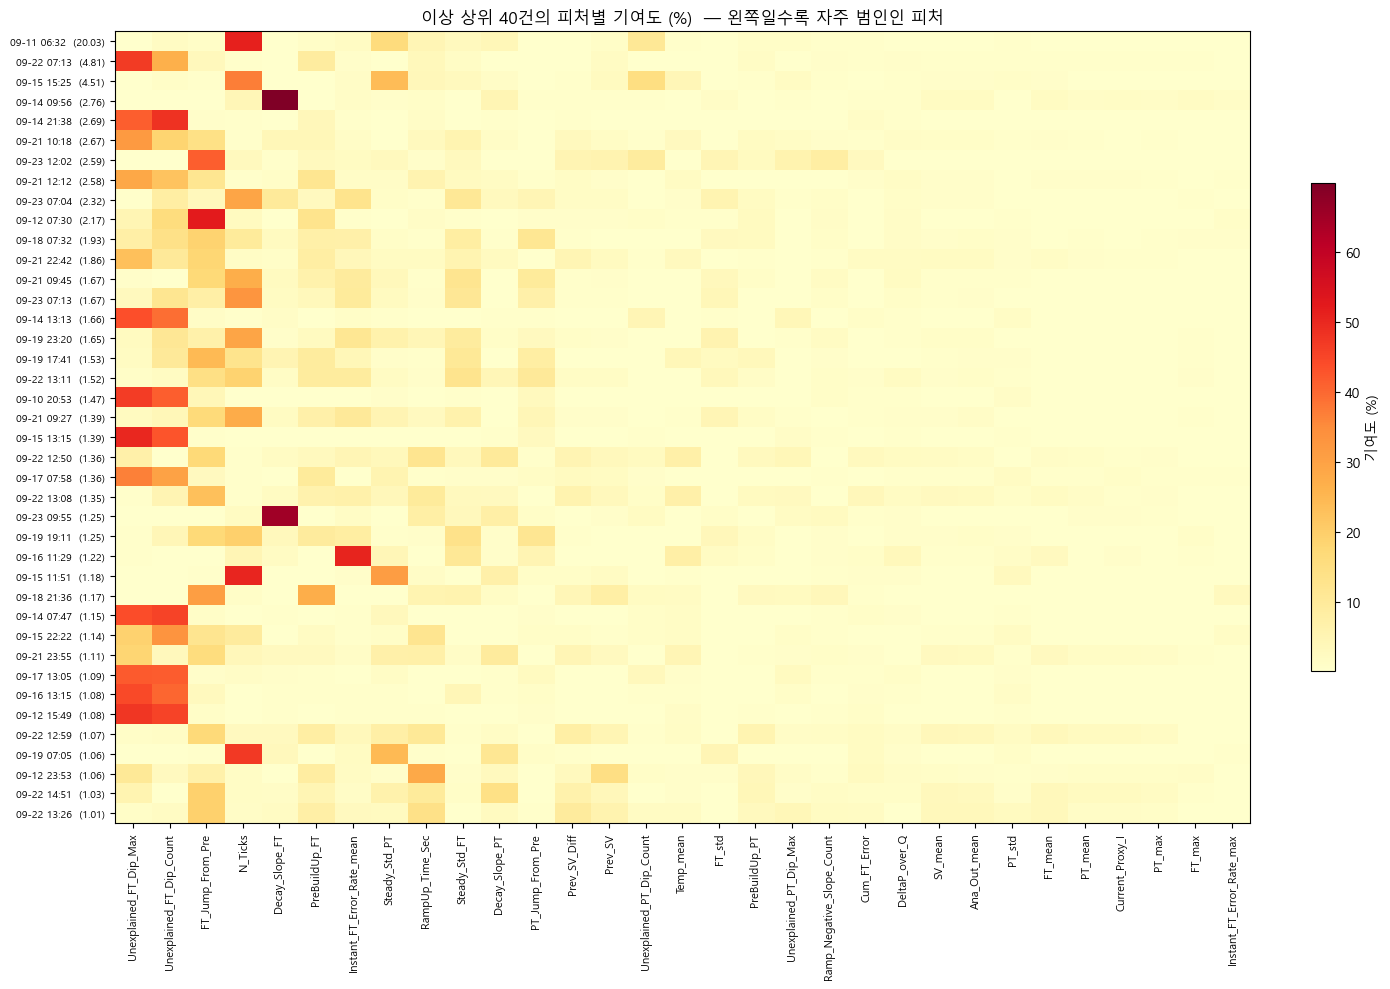

In [9]:
# 전체 기간 기준으로도 한 번 (어떤 피처가 상습 범인인지)
fig, contrib_all = V.contribution_heatmap(
    per_feat, FEATURE_COLS, cyc["Recon_Error"].values, cyc["Start_Time"].values,
    THRESHOLD, top_n=40)
plt.show()

## 4. 개별 이상 시점 원본 확대

이상으로 찍힌 사이클의 **원본 틱**을 앞뒤로 펼쳐 본다. 실제로 압력이 어떻게 움직였는지,
사출(초록선)과 어떤 관계였는지 눈으로 확인하는 단계다.

In [10]:
worst = cyc[cyc["Recon_Error"] > THRESHOLD].sort_values("Recon_Error", ascending=False)
print("이상 상위 10건")
print(worst[["Start_Time", "Recon_Error", "N_Ticks", "Decay_Slope_PT",
             "Unexplained_FT_Dip_Count", "RampUp_Time_Sec"]].head(10).to_string())

이상 상위 10건
                         Start_Time  Recon_Error  N_Ticks  Decay_Slope_PT  Unexplained_FT_Dip_Count  RampUp_Time_Sec
Cycle_ID                                                                                                            
2742     2026-09-11 06:32:26.990351    20.034355       82      -19.274583                         0         2.119686
57358    2026-09-22 07:13:31.848542     4.810037       16       -8.653074                         1         0.514341
23866    2026-09-15 15:25:36.154970     4.511793       51      -34.072079                         0         1.580372
16204    2026-09-14 09:56:19.951911     2.761600       18      -73.216011                         0         2.117105
20162    2026-09-14 21:38:55.511015     2.686448       16      -24.893640                         1         1.536876
52616    2026-09-21 10:18:51.454193     2.666955       16       -2.846631                         2         2.066891
65416    2026-09-23 12:02:22.993962     2.590690      


=== #1  2026-09-11 06:32:26.990351  오차 20.034 ===
   N_Ticks: 51.1%  (값 82.000)
   Steady_Std_PT: 16.1%  (값 2.420)
   Unexplained_PT_Dip_Count: 10.7%  (값 3.000)


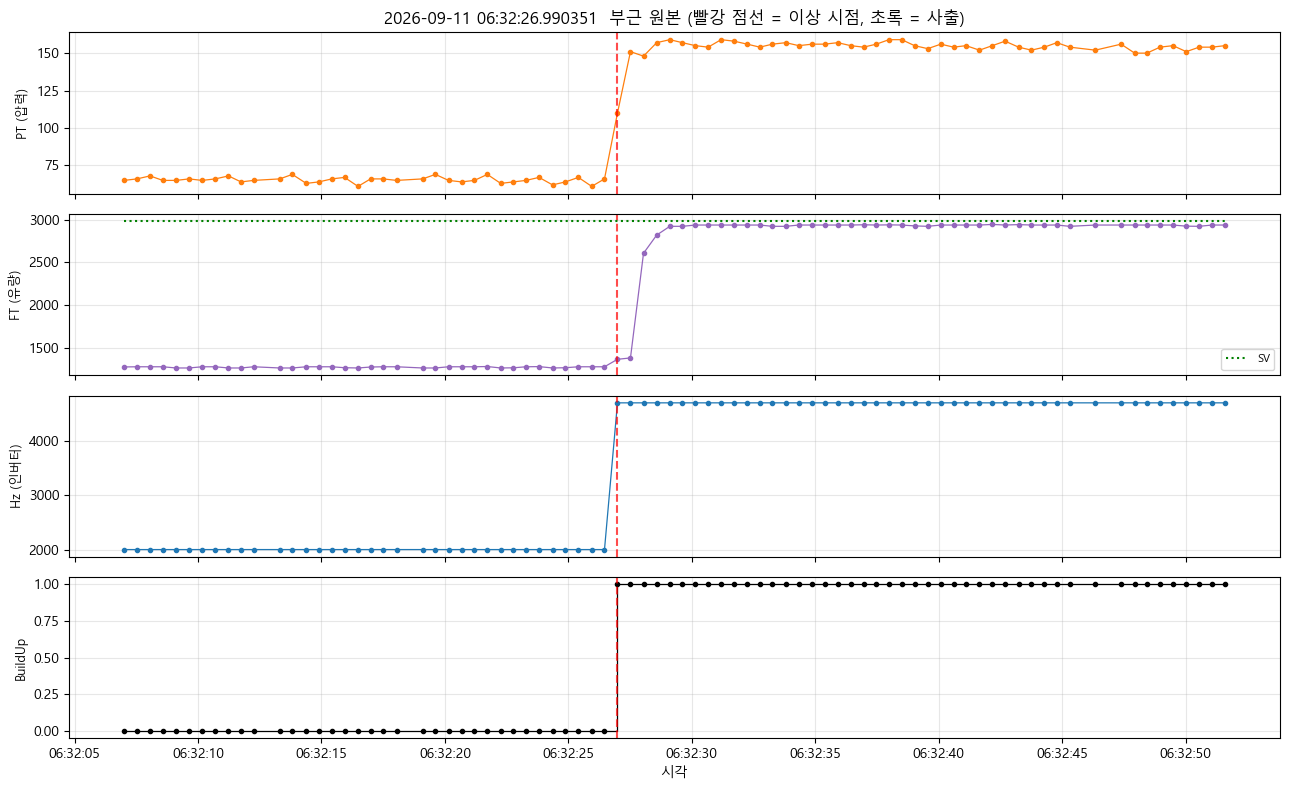


=== #2  2026-09-22 07:13:31.848542  오차 4.810 ===
   Unexplained_FT_Dip_Max: 46.9%  (값 0.182)
   Unexplained_FT_Dip_Count: 26.7%  (값 1.000)
   PreBuildUp_FT: 8.9%  (값 1285.000)


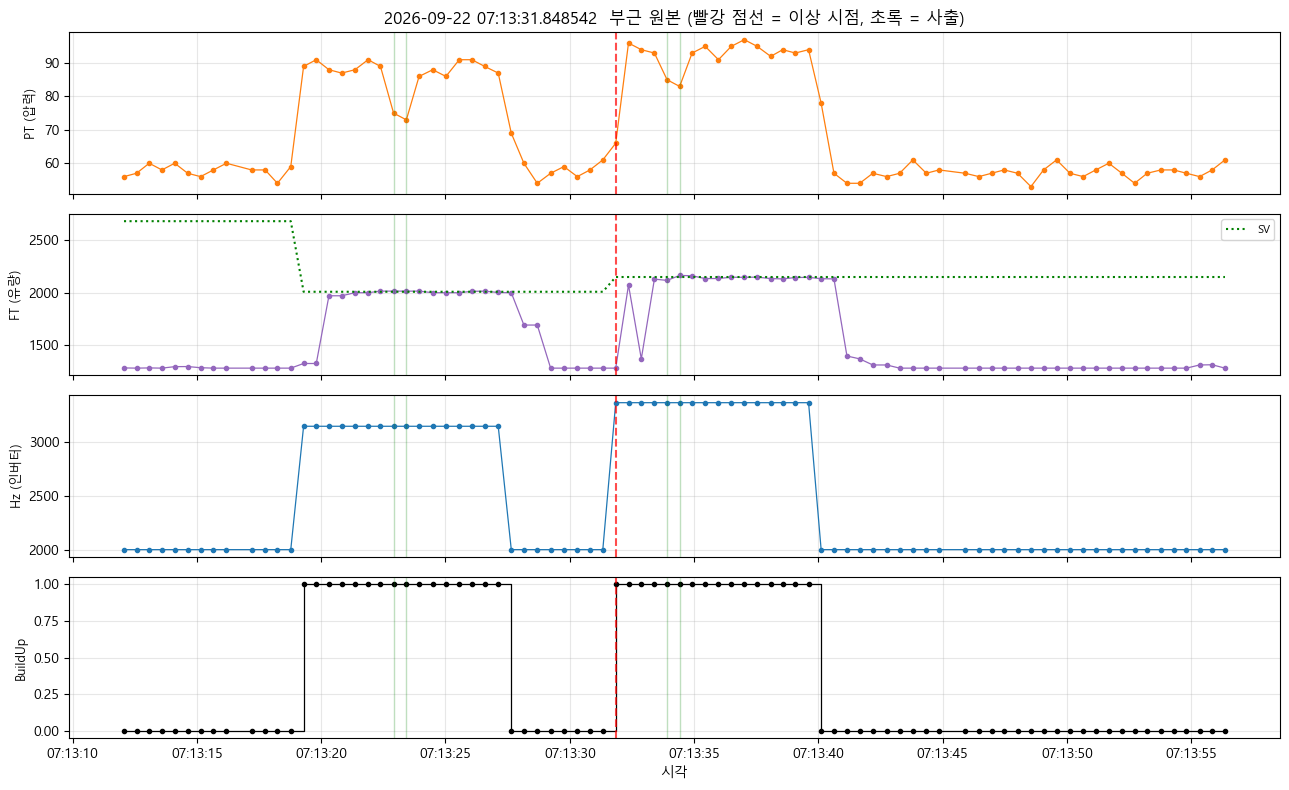


=== #3  2026-09-15 15:25:36.154970  오차 4.512 ===
   N_Ticks: 37.0%  (값 51.000)
   Steady_Std_PT: 23.8%  (값 1.774)
   Unexplained_PT_Dip_Count: 14.8%  (값 2.000)


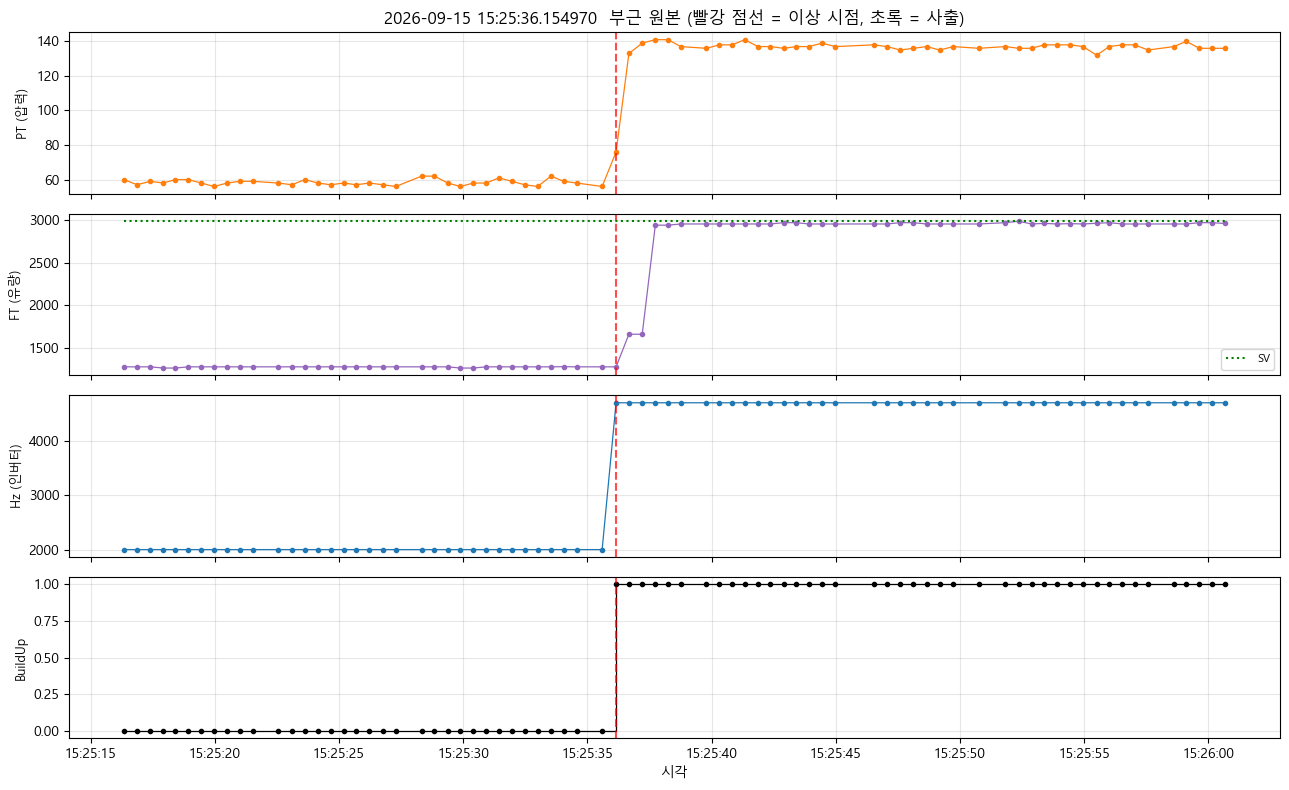

In [11]:
N_ZOOM = 3     # 상위 몇 건을 확대해 볼지
for i in range(min(N_ZOOM, len(worst))):
    row = worst.iloc[i]
    print(f"\n=== #{i+1}  {row['Start_Time']}  오차 {row['Recon_Error']:.3f} ===")
    contrib = pd.Series(per_feat[cyc.index.get_indexer([worst.index[i]])[0]], index=FEATURE_COLS)
    contrib = (contrib / contrib.sum() * 100).sort_values(ascending=False)
    for f, v in contrib.head(3).items():
        print(f"   {f}: {v:.1f}%  (값 {row[f]:.3f})")
    V.zoom_raw(raw, row["Start_Time"], PUMP_ID, before_sec=20, after_sec=25, inj_col=INJ_COL)
    plt.show()